# FE-8：两阶段特征筛选（先 FE8，再 IF×EDA×A）

参照协议：FE-6 purged walk-forward CV（2h embargo）。

## 阶段 1：纯 FE8 筛选（在 BASE 上）

- 对比基线：`0_BASE`（V1–V28 + Amount + Time）
- 测试 **FE8 的 1..5 列子集**（共 31 组 + 基线 = 32 组）
- **不含 IF**（专门看 FE8 边际贡献）
- 稳定性：**2 模型 × 2 seed（42, 2026）**，Δ vs BASE

## 阶段 2：入选 FE8 × IF × EDA × A

- **除 `0_BASE` 与 MT-4 参照外，每组必须含入选 FE8 之一**
- 无单独 IF、无 IF×EDA（无 FE8）参照
- **EDA 原子**（5 个，含 `is_micro_testing`；`bands` 成对）→ 32 种子集
- **主网格**：shortlist × 32 EDA × `{+A1, +A_top2}`（**无「不加 A」**）
- **定稿参照**：MT-4 = `IF + hours_since_start + log1p_amount + A_top2`
- **稳定性**：2 模型 × 2 seed（42, 2026）

## FE8 新特征（5 列）

`v14_x_v10`, `v14_x_v4`, `v10_x_v4`, `abs_v14_minus_v10`, `v14_x_log1p_amount`

## 输出

`output/fe8/fe8_stage1_*`、`fe8_stage2_*`、定稿 JSON、图表。

> 矩阵变更后请删除 `fe8_stage2_checkpoint.csv` 再跑。阶段1已硬编码 Top-3 FE8 shortlist。


In [31]:
# --- 0. 环境、路径与实验开关 ---
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb
from purgedcv import WalkForwardSplit
from purgedcv.diagnostics import assert_no_temporal_leakage
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'input' / 'creditcard.csv').exists():
            return candidate
    raise FileNotFoundError('无法找到 input/creditcard.csv，请确认 notebook 在项目内运行')


PROJECT_ROOT = find_project_root()
FEATURE_DIR = PROJECT_ROOT / 'src' / 'feature-engineering'
DATA_PATH = PROJECT_ROOT / 'input' / 'creditcard.csv'
MT4_CONFIG_PATH = PROJECT_ROOT / 'src' / 'model-training' / 'model_training_if_log1p_atop2_purgedcv_mt4.json'
OUTPUT_PATH = FEATURE_DIR / 'MODEL_FEATURES_V3_contribution_fe8.json'
RESULT_PATH = FEATURE_DIR / 'FE8_CONTRIBUTION_STABILITY_RESULTS.json'

RUN_SEEDS = [42, 2026]
MODELS = ['LightGBM', 'XGBoost']
CV_N_SPLITS = 5
CV_RANDOM_STATE = 42
CV_EMBARGO = pd.Timedelta(hours=2)
CV_PURGE_HORIZON = pd.Timedelta(0)

EARLY_STOPPING_ROUNDS = 50
MAX_BOOST_ROUNDS = 1500
ES_FRAC = 0.25
DEFAULT_CLASSIFICATION_THRESHOLD = 0.5
TOP_V_K = 2  # Family A 只保留 A1、A2（A_top2 = 前两列）

IF_RANDOM_STATE = 42
IF_N_ESTIMATORS = 200
IF_MAX_SAMPLES = 0.5
IF_CONTAMINATION = 'auto'
IF_MAX_NORMAL_SAMPLES = 50_000

BASELINE_LABEL = '0_BASE'
MT4_LABEL = 'MT4_IF+hours+log1p+A_top2'

# 阶段 1 已完成：硬编码 Top-3 FE8（fe8_stage1_dual_summary 稳定性排序）
MANUAL_FE8_SHORTLIST = [
    ['abs_v14_minus_v10', 'v14_x_log1p_amount', 'v14_x_v10'],
    ['abs_v14_minus_v10', 'v10_x_v4', 'v14_x_log1p_amount', 'v14_x_v10'],
    ['abs_v14_minus_v10', 'v10_x_v4', 'v14_x_log1p_amount'],
]
SKIP_STAGE1_RUN = True
# Top-5 扩展 seeds 复验：已有结果时跳过跑批
SKIP_TOP5_RUN = True

OUTPUT_DIR = FEATURE_DIR / 'output' / 'fe8'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 阶段 1
STAGE1_COMBO_CSV = OUTPUT_DIR / 'fe8_stage1_combo_specs.csv'
STAGE1_COMBO_MD = OUTPUT_DIR / 'fe8_stage1_combo_specs.md'
STAGE1_CHECKPOINT = OUTPUT_DIR / 'fe8_stage1_checkpoint.csv'
STAGE1_RAW_CSV = OUTPUT_DIR / 'fe8_stage1_raw.csv'
STAGE1_DUAL_CSV = OUTPUT_DIR / 'fe8_stage1_dual_summary.csv'
STAGE1_SHORTLIST_JSON = OUTPUT_DIR / 'fe8_stage1_shortlist.json'

# 阶段 2
STAGE2_COMBO_CSV = OUTPUT_DIR / 'fe8_stage2_combo_specs.csv'
STAGE2_COMBO_MD = OUTPUT_DIR / 'fe8_stage2_combo_specs.md'
STAGE2_CHECKPOINT = OUTPUT_DIR / 'fe8_stage2_checkpoint.csv'
STAGE2_RAW_CSV = OUTPUT_DIR / 'fe8_stage2_raw.csv'
STAGE2_SUMMARY_CSV = OUTPUT_DIR / 'fe8_stage2_summary.csv'
STAGE2_DUAL_CSV = OUTPUT_DIR / 'fe8_stage2_dual_summary.csv'

# Top-5 扩展 seeds 复验
TOP5_VALIDATION_SEEDS = [7, 13, 42, 77, 123, 256, 2026, 3141]
TOP5_CHECKPOINT = OUTPUT_DIR / 'fe8_top5_validation_checkpoint.csv'
TOP5_RAW_CSV = OUTPUT_DIR / 'fe8_top5_validation_raw.csv'
TOP5_DUAL_CSV = OUTPUT_DIR / 'fe8_top5_validation_dual_summary.csv'
TOP5_JSON = OUTPUT_DIR / 'fe8_top5_validation_result.json'
print('项目根目录:', PROJECT_ROOT)
print('对比基线:', BASELINE_LABEL)
print('定稿参照:', MT4_LABEL)
print('阶段1: FE8 k=1..5 on BASE | SKIP_STAGE1_RUN:', SKIP_STAGE1_RUN)
print('输出目录:', OUTPUT_DIR)



项目根目录: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets
对比基线: 0_BASE
定稿参照: MT4_IF+hours+log1p+A_top2
阶段1: FE8 k=1..5 on BASE | SKIP_STAGE1_RUN: True
输出目录: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/output/fe8


In [32]:
# --- 1. 数据读取与特征块定义 ---
def read_creditcard_csv(path: Path) -> pd.DataFrame:
    for kwargs in (
        {'encoding': 'utf-8'},
        {'encoding': 'utf-8', 'encoding_errors': 'replace'},
        {'encoding': 'latin-1'},
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, 'failed to decode creditcard.csv')


def build_eda_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out['log1p_amount'] = np.log1p(out['Amount'])
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    out['is_micro_testing'] = out['Amount'] < 1
    out['is_one_euro'] = out['Amount'] == 1.0
    out['is_amount_1_30'] = (out['Amount'] > 1) & (out['Amount'] <= 30)
    out['is_amount_75_110'] = (out['Amount'] >= 75) & (out['Amount'] <= 110)
    return out


def build_cross_features(data: pd.DataFrame, top_v: list, gate_col='is_one_euro', prefix='one_euro'):
    out = data.copy()
    gate = out[gate_col].astype(float)
    new_cols = []
    for v in top_v:
        name = f'{prefix}_{v}'
        out[name] = gate * out[v]
        new_cols.append(name)
    return out, new_cols


def build_fe8_contribution_features(data: pd.DataFrame):
    out = data.copy()
    out['v14_x_v10'] = out['V14'] * out['V10']
    out['v14_x_v4'] = out['V14'] * out['V4']
    out['v10_x_v4'] = out['V10'] * out['V4']
    out['abs_v14_minus_v10'] = (out['V14'] - out['V10']).abs()
    out['v14_x_log1p_amount'] = out['V14'] * out['log1p_amount']
    feats = ['v14_x_v10', 'v14_x_v4', 'v10_x_v4', 'abs_v14_minus_v10', 'v14_x_log1p_amount']
    return out, feats


def pick_top_v_features(data, feature_cols, k=TOP_V_K, model_name='LightGBM', random_state=42):
    data = sort_by_time(data)
    n = len(data)
    test_size = max(1, n // (CV_N_SPLITS + 1))
    tr_idx = np.arange(0, n - test_size)
    X_tr, y_tr = data.iloc[tr_idx][feature_cols], data.iloc[tr_idx]['Class']
    X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state)
    clf = make_classifier(model_name, y_fit, random_state=random_state)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
    imp = pd.Series(clf.feature_importances_, index=feature_cols)
    top_v = list(imp[[c for c in feature_cols if c.startswith('V')]].sort_values(ascending=False).head(k).index)
    print(f'Top-{k} V ({model_name} gain): {top_v}')
    return top_v


df_raw = read_creditcard_csv(DATA_PATH)
V_COLS = [c for c in df_raw.columns if c.startswith('V')]
BASE_FEATURES = V_COLS + ['Amount', 'Time']

FE_EDA = ['log1p_amount', 'hours_since_start', 'is_micro_testing', 'is_one_euro', 'is_amount_1_30', 'is_amount_75_110']
AMOUNT_BAND_FEATURES = ['is_amount_1_30', 'is_amount_75_110']
EDA_CURATED = ['hours_since_start', 'is_one_euro']
FE_IF = ['if_oof_score']
FE_IF_GATE = ['if_oof_score_x_one_euro']
A_TOP2 = ['one_euro_V14', 'one_euro_V4']
MT4_FINAL_EXTRA = ['if_oof_score', 'hours_since_start', 'log1p_amount'] + A_TOP2
IF_HOURS_LOG = ['if_oof_score', 'hours_since_start', 'log1p_amount']

with open(MT4_CONFIG_PATH, 'r', encoding='utf-8') as f:
    _mt4 = json.load(f)
_mt4_extra = [c for c in _mt4['MODEL_FEATURES'] if c not in BASE_FEATURES]
assert MT4_FINAL_EXTRA == _mt4_extra, f'MT4 mismatch: {_mt4_extra}'

print(f'行数: {len(df_raw):,} | 欺诈: {int(df_raw["Class"].sum())} | 欺诈率: {df_raw["Class"].mean():.4f}')
print('MT-4 定稿增量:', MT4_FINAL_EXTRA)


行数: 284,807 | 欺诈: 492 | 欺诈率: 0.0017
MT-4 定稿增量: ['if_oof_score', 'hours_since_start', 'log1p_amount', 'one_euro_V14', 'one_euro_V4']


In [33]:
# --- 2. purged walk-forward CV 与模型评估 ---
_CV_BOUND_DATA = None


def sort_by_time(data: pd.DataFrame) -> pd.DataFrame:
    return data.sort_values('Time', kind='mergesort').reset_index(drop=True)


def bind_cv_data(data: pd.DataFrame) -> pd.DataFrame:
    global _CV_BOUND_DATA
    out = sort_by_time(data)
    _CV_BOUND_DATA = out
    return out


def build_cv_timestamps(data: pd.DataFrame):
    t = pd.to_timedelta(data['Time'].astype(float), unit='s')
    return t.copy(), t.copy()


def iter_purged_cv_folds(n_samples=None, n_splits=CV_N_SPLITS, data=None):
    bound = data if data is not None else _CV_BOUND_DATA
    if bound is None:
        raise RuntimeError('请先调用 bind_cv_data()')
    n = n_samples if n_samples is not None else len(bound)
    pred, evalu = build_cv_timestamps(bound)
    test_size = max(1, n // (n_splits + 1))
    cv = WalkForwardSplit(
        n_splits=n_splits, test_size=test_size, window='expanding',
        prediction_times=pred, evaluation_times=evalu,
        purge_horizon=CV_PURGE_HORIZON, embargo=CV_EMBARGO,
    )
    for tr_idx, va_idx in cv.split(np.arange(n)):
        assert_no_temporal_leakage(tr_idx, va_idx, prediction_times=pred, evaluation_times=evalu, purge_horizon=CV_PURGE_HORIZON)
        yield tr_idx, va_idx


def split_early_stop_set(X_tr, y_tr, es_frac=ES_FRAC, random_state=42):
    return train_test_split(X_tr, y_tr, test_size=es_frac, random_state=random_state, stratify=y_tr)


def make_classifier(model_name: str, y_train: pd.Series, random_state: int = 42):
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    if model_name == 'LightGBM':
        return lgb.LGBMClassifier(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
            num_leaves=31, min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1, class_weight='balanced',
            random_state=random_state, verbose=-1, n_jobs=-1,
        )
    return xgb.XGBClassifier(
        n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
        min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=spw,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS, random_state=random_state,
        eval_metric='logloss', verbosity=0, n_jobs=-1,
    )


def fit_classifier(clf, model_name: str, X_tr, y_tr, X_es=None, y_es=None):
    if X_es is None or y_es is None:
        clf.fit(X_tr, y_tr)
        return clf
    if model_name == 'LightGBM':
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric='binary_logloss',
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)])
    else:
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
    return clf


def best_f1_threshold(y_true, proba):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    mask = np.isfinite(proba)
    y_eval, p_eval = y_true[mask], proba[mask]
    prec, rec, thr = precision_recall_curve(y_eval, p_eval)
    if len(thr) == 0:
        return DEFAULT_CLASSIFICATION_THRESHOLD, 0.0
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    i = int(np.nanargmax(f1))
    return float(thr[i]), float(f1[i])


def metrics_at_threshold(y_true, proba, threshold):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    mask = np.isfinite(proba)
    pred = proba[mask] >= threshold
    y_eval = y_true[mask]
    tn, fp, fn, tp = confusion_matrix(y_eval, pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        'F1@best': float(f1), 'Precision@best': float(precision), 'Recall@best': float(recall),
        'FP': int(fp), 'FN': int(fn), 'n_eval': int(mask.sum()), 'n_excluded': int((~mask).sum()),
    }


def cross_val_eval(model_name: str, data: pd.DataFrame, feature_cols: list, random_state: int = 42):
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    fold_scores = []
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(len(X), n_splits=CV_N_SPLITS), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state + fold)
        clf = make_classifier(model_name, y_fit, random_state=random_state + fold)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba_va = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba_va
        fold_scores.append(float(average_precision_score(y_va, proba_va)))
    arr = np.array(fold_scores, dtype=float)
    threshold, _ = best_f1_threshold(y, oof)
    cls = metrics_at_threshold(y, oof, threshold)
    return {
        '模型': model_name, '特征数': len(feature_cols),
        'AUC-PR_mean': float(arr.mean()), 'AUC-PR_std': float(arr.std(ddof=0)),
        'AUC-PR_min': float(arr.min()), 'fold_AUC-PR': fold_scores,
        'best_threshold': threshold, **cls,
    }


In [34]:
# --- 3. OOF IF 与完整特征表 ---
def oof_if_anomaly_score(data, feature_cols=None, random_state=IF_RANDOM_STATE):
    feature_cols = feature_cols or V_COLS
    X = data[feature_cols].values.astype(np.float64)
    y = data['Class'].values
    oof = np.full(len(y), np.nan, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(data=data, n_splits=CV_N_SPLITS), start=1):
        normal_tr = tr_idx[y[tr_idx] == 0]
        if len(normal_tr) > IF_MAX_NORMAL_SAMPLES:
            rng = np.random.default_rng(random_state + fold)
            normal_tr = rng.choice(normal_tr, size=IF_MAX_NORMAL_SAMPLES, replace=False)
        scaler = StandardScaler()
        X_normal = scaler.fit_transform(X[normal_tr])
        X_valid = scaler.transform(X[va_idx])
        iforest = IsolationForest(
            n_estimators=IF_N_ESTIMATORS, max_samples=IF_MAX_SAMPLES,
            contamination=IF_CONTAMINATION, random_state=random_state + fold, n_jobs=-1,
        )
        iforest.fit(X_normal)
        oof[va_idx] = -iforest.score_samples(X_valid)
        print(f'  IF fold {fold}/{CV_N_SPLITS} 完成，正常训练样本={len(normal_tr):,}')
    return oof


df_fe8 = build_eda_features(df_raw)
df_fe8 = bind_cv_data(df_fe8)

TOP_V = pick_top_v_features(df_fe8, BASE_FEATURES, k=TOP_V_K, model_name='LightGBM')
df_fe8, CROSS_FAMILY_A = build_cross_features(df_fe8, TOP_V, gate_col='is_one_euro', prefix='one_euro')
df_fe8, FE8_NEW_FEATURES = build_fe8_contribution_features(df_fe8)

print('开始计算 if_oof_score（purged OOF IF）...')
df_fe8['if_oof_score'] = oof_if_anomaly_score(df_fe8, V_COLS, random_state=IF_RANDOM_STATE)

A1_COL = CROSS_FAMILY_A[0]
A2_COL = CROSS_FAMILY_A[1]
A_TOP2 = list(CROSS_FAMILY_A[:2])

with open(MT4_CONFIG_PATH, 'r', encoding='utf-8') as f:
    _mt4 = json.load(f)
_mt4_extra = [c for c in _mt4['MODEL_FEATURES'] if c not in BASE_FEATURES]
assert MT4_FINAL_EXTRA == _mt4_extra, f'MT4 配置与 notebook 不一致: {_mt4_extra}'

print('A1:', A1_COL, '| A2:', A2_COL, '| A_top2:', A_TOP2)
print('FE-8 新特征:', FE8_NEW_FEATURES)


Top-2 V (LightGBM gain): ['V4', 'V14']
开始计算 if_oof_score（purged OOF IF）...
  IF fold 1/5 完成，正常训练样本=47,326
  IF fold 2/5 完成，正常训练样本=50,000
  IF fold 3/5 完成，正常训练样本=50,000
  IF fold 4/5 完成，正常训练样本=50,000
  IF fold 5/5 完成，正常训练样本=50,000
A1: one_euro_V4 | A2: one_euro_V14 | A_top2: ['one_euro_V4', 'one_euro_V14']
FE-8 新特征: ['v14_x_v10', 'v14_x_v4', 'v10_x_v4', 'abs_v14_minus_v10', 'v14_x_log1p_amount']


In [35]:
# --- 4. 组合规格：共享工具 + 阶段1矩阵 ---
from itertools import combinations


def _dedupe(cols):
    out, seen = [], set()
    for c in cols:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


def _subset_label(cols):
    return '+'.join(sorted(cols)) if cols else 'none'


def _fe8_subsets():
    return [list(s) for k in range(1, len(FE8_NEW_FEATURES) + 1) for s in combinations(FE8_NEW_FEATURES, k)]


# EDA 原子：bands 成对；含 is_micro_testing
EDA_ATOMS = [
    ('log1p', ['log1p_amount']),
    ('hours', ['hours_since_start']),
    ('one_euro', ['is_one_euro']),
    ('micro', ['is_micro_testing']),
    ('bands', list(AMOUNT_BAND_FEATURES)),
]


def iter_eda_subsets():
    for mask in range(2 ** len(EDA_ATOMS)):
        cols, tags = [], []
        for i, (tag, atom_cols) in enumerate(EDA_ATOMS):
            if mask & (1 << i):
                cols.extend(atom_cols)
                tags.append(tag)
        yield _dedupe(cols), '+'.join(tags) if tags else 'none'


def _make_record(records, seen, category, label, extra, stage):
    extra = _dedupe(extra)
    fe8_cols = [c for c in extra if c in FE8_NEW_FEATURES]
    hc_cols = [c for c in extra if c not in FE8_NEW_FEATURES]
    key = (stage, tuple(sorted(extra)))
    if key in seen:
        return
    seen.add(key)
    records.append({
        'combo_id': len(records), 'stage': stage, 'category': category, 'label': label,
        'handcrafted_cols': hc_cols, 'fe8_cols': fe8_cols, 'extra_cols': extra,
        'n_handcrafted': len(hc_cols), 'n_fe8': len(fe8_cols), 'n_extra': len(extra),
    })


def build_stage1_specs():
    records, seen = [], set()
    _make_record(records, seen, 'baseline', BASELINE_LABEL, [], stage=1)
    for fe8_subset in _fe8_subsets():
        k = len(fe8_subset)
        label = f'S1_FE8_k{k}_{_subset_label(fe8_subset)}'
        _make_record(records, seen, 'stage1_fe8_on_base', label, list(fe8_subset), stage=1)
    return records


def build_stage2_specs(selected_fe8_lists):
    records, seen = [], set()
    fe_if = list(FE_IF)
    atop2_short = '+'.join(c.replace('one_euro_', '') for c in A_TOP2)

    _make_record(records, seen, 'baseline', BASELINE_LABEL, [], stage=2)
    _make_record(records, seen, 'mt4_ref', MT4_LABEL, MT4_FINAL_EXTRA, stage=2)

    a_variants = [
        ('+A1', [A1_COL]),
        (f'+A_top2({atop2_short})', A_TOP2),
    ]

    for fe8_subset in selected_fe8_lists:
        fe8_tag = _subset_label(fe8_subset)
        for eda_cols, eda_tag in iter_eda_subsets():
            for a_suffix, a_cols in a_variants:
                label = f'IF+Ed[{eda_tag}]+FE8[{fe8_tag}]{a_suffix}'
                extra = fe_if + eda_cols + list(fe8_subset) + a_cols
                _make_record(records, seen, 'stage2_main', label, extra, stage=2)

    return records


def export_combo_catalog(spec_records, csv_path, md_path, title):
    rows = [{
        'combo_id': r['combo_id'], 'stage': r['stage'], 'category': r['category'], 'label': r['label'],
        'n_handcrafted': r['n_handcrafted'], 'n_fe8': r['n_fe8'], 'n_extra': r['n_extra'],
        'handcrafted_cols': ' | '.join(r['handcrafted_cols']) if r['handcrafted_cols'] else '(none)',
        'fe8_cols': ' | '.join(r['fe8_cols']) if r['fe8_cols'] else '(none)',
        'extra_cols': ' | '.join(r['extra_cols']),
    } for r in spec_records]
    catalog_df = pd.DataFrame(rows)
    catalog_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    lines = [f'# {title}（共 {len(spec_records)} 组）\n\n', f'- 对比基线：{BASELINE_LABEL}\n\n']
    for cat in catalog_df['category'].unique():
        sub = catalog_df[catalog_df['category'] == cat]
        lines.append(f'## {cat}（{len(sub)} 组）\n\n')
        for _, row in sub.iterrows():
            lines.append(f"### [{row['combo_id']}] {row['label']}\n")
            lines.append(f"- 手工：{row['handcrafted_cols']}\n")
            lines.append(f"- FE8：{row['fe8_cols']}\n")
            lines.append(f"- 全部：{row['extra_cols']}\n\n")
    md_path.write_text(''.join(lines), encoding='utf-8')
    return catalog_df


def eval_spec_once(rec, model_name, seed):
    cols = BASE_FEATURES + [c for c in rec['extra_cols'] if c not in BASE_FEATURES]
    missing = [c for c in cols if c not in df_fe8.columns]
    if missing:
        raise KeyError(f"{rec['label']} 缺失列: {missing}")
    res = cross_val_eval(model_name, df_fe8, cols, random_state=seed)
    return {
        'combo_id': rec['combo_id'], 'stage': rec['stage'], 'category': rec['category'],
        '特征组合': rec['label'], '模型': model_name, 'seed': seed,
        'n_handcrafted': rec['n_handcrafted'], 'n_fe8': rec['n_fe8'], 'n_extra': rec['n_extra'],
        'handcrafted_cols': ' | '.join(rec['handcrafted_cols']),
        'fe8_cols': ' | '.join(rec['fe8_cols']),
        'extra_cols': ' | '.join(rec['extra_cols']),
        **res,
    }


def run_stability_matrix(spec_records, checkpoint_path, models=MODELS, seeds=RUN_SEEDS):
    done = {}
    if checkpoint_path.is_file():
        prev = pd.read_csv(checkpoint_path)
        if '特征组合' in prev.columns:
            for _, row in prev.iterrows():
                done[(row['特征组合'], row['模型'], int(row['seed']))] = row.to_dict()
            print(f'checkpoint 恢复 {len(done)} 行 | {checkpoint_path}')

    rows = list(done.values())
    total = len(spec_records) * len(models) * len(seeds)
    step = len(rows)

    for rec in spec_records:
        for model_name in models:
            for seed in seeds:
                key = (rec['label'], model_name, seed)
                if key in done:
                    continue
                step += 1
                print(f'[{step}/{total}] {model_name} seed={seed} | {rec["label"]}', flush=True)
                row = eval_spec_once(rec, model_name, seed)
                rows.append(row)
                done[key] = row
                pd.DataFrame(rows).to_csv(checkpoint_path, index=False, encoding='utf-8-sig')

    return pd.DataFrame(rows)


def summarize_stability(raw: pd.DataFrame, baseline_label=BASELINE_LABEL):
    base = (
        raw[raw['特征组合'] == baseline_label]
        .groupby(['模型', 'seed'], as_index=False)['AUC-PR_mean']
        .mean()
        .rename(columns={'AUC-PR_mean': 'BASELINE_AUC_seed'})
    )
    if base.empty:
        raise ValueError(f'基线 {baseline_label} 无结果')

    merged = raw.merge(base, on=['模型', 'seed'], how='left')
    merged['delta_AUC_vs_BASE'] = merged['AUC-PR_mean'] - merged['BASELINE_AUC_seed']

    summary = (
        merged.groupby(['特征组合', '模型'], as_index=False)
        .agg(
            combo_id=('combo_id', 'first'), stage=('stage', 'first'), category=('category', 'first'),
            n_handcrafted=('n_handcrafted', 'first'), n_fe8=('n_fe8', 'first'), n_extra=('n_extra', 'first'),
            handcrafted_cols=('handcrafted_cols', 'first'), fe8_cols=('fe8_cols', 'first'),
            extra_cols=('extra_cols', 'first'),
            AUC_mean=('AUC-PR_mean', 'mean'), AUC_std_across_seed=('AUC-PR_mean', 'std'),
            delta_mean_AUC=('delta_AUC_vs_BASE', 'mean'), delta_std_AUC=('delta_AUC_vs_BASE', 'std'),
            positive_seed_ratio=('delta_AUC_vs_BASE', lambda s: float((s > 0).mean())),
            F1_mean=('F1@best', 'mean'), FP_mean=('FP', 'mean'), FN_mean=('FN', 'mean'),
        )
    )
    summary['conservative_score'] = summary['delta_mean_AUC'] - summary['delta_std_AUC'].fillna(0.0)
    return merged, summary.sort_values(['模型', 'conservative_score'], ascending=[True, False]).reset_index(drop=True)


def build_dual_model_summary(stability_summary: pd.DataFrame):
    lgb_s = stability_summary[stability_summary['模型'] == 'LightGBM'].set_index('特征组合')
    xgb_s = stability_summary[stability_summary['模型'] == 'XGBoost'].set_index('特征组合')
    rows = []
    for label in lgb_s.index.intersection(xgb_s.index):
        rows.append({
            'combo_id': int(lgb_s.loc[label, 'combo_id']),
            'stage': lgb_s.loc[label, 'stage'], 'category': lgb_s.loc[label, 'category'],
            'combo_label': label,
            'n_handcrafted': int(lgb_s.loc[label, 'n_handcrafted']),
            'n_fe8': int(lgb_s.loc[label, 'n_fe8']), 'n_extra': int(lgb_s.loc[label, 'n_extra']),
            'handcrafted_cols': lgb_s.loc[label, 'handcrafted_cols'],
            'fe8_cols': lgb_s.loc[label, 'fe8_cols'], 'extra_cols': lgb_s.loc[label, 'extra_cols'],
            'delta_LGB_AUC': float(lgb_s.loc[label, 'delta_mean_AUC']),
            'delta_XGB_AUC': float(xgb_s.loc[label, 'delta_mean_AUC']),
            'delta_mean_AUC': float(np.mean([lgb_s.loc[label, 'delta_mean_AUC'], xgb_s.loc[label, 'delta_mean_AUC']])),
            'LGB_positive_seed_ratio': float(lgb_s.loc[label, 'positive_seed_ratio']),
            'XGB_positive_seed_ratio': float(xgb_s.loc[label, 'positive_seed_ratio']),
            'both_models_positive': bool(lgb_s.loc[label, 'delta_mean_AUC'] > 0 and xgb_s.loc[label, 'delta_mean_AUC'] > 0),
            'conservative_score': float(np.mean([lgb_s.loc[label, 'conservative_score'], xgb_s.loc[label, 'conservative_score']])),
        })
    return pd.DataFrame(rows).sort_values(
        ['both_models_positive', 'conservative_score', 'delta_mean_AUC'], ascending=False
    ).reset_index(drop=True)


def parse_fe8_cols(fe8_cols_str):
    if not isinstance(fe8_cols_str, str) or not fe8_cols_str.strip() or fe8_cols_str == '(none)':
        return []
    return [c.strip() for c in fe8_cols_str.split('|')]


def select_fe8_shortlist(dual_summary, top_n=FE8_TOP_N_MAX):
    if MANUAL_FE8_SHORTLIST is not None:
        out = []
        for item in MANUAL_FE8_SHORTLIST:
            cols = list(item) if isinstance(item, (list, tuple)) else [item]
            out.append(_dedupe(cols))
        print('使用 MANUAL_FE8_SHORTLIST:', out)
        return out

    pool = dual_summary[
        (dual_summary['combo_label'] != BASELINE_LABEL) & (dual_summary['n_fe8'] > 0)
    ].copy()

    eligible = pool[
        pool['both_models_positive']
        & (pool['LGB_positive_seed_ratio'] >= 2 / 3)
        & (pool['XGB_positive_seed_ratio'] >= 2 / 3)
    ].sort_values(['conservative_score', 'delta_mean_AUC'], ascending=False)

    if eligible.empty:
        print('阶段1：无满足稳定性门槛的 FE8 组合，回退为 delta_mean_AUC Top-3')
        eligible = pool.sort_values('delta_mean_AUC', ascending=False).head(3)

    shortlisted, seen = [], set()
    for _, row in eligible.iterrows():
        key = tuple(sorted(parse_fe8_cols(row['fe8_cols'])))
        if not key or key in seen:
            continue
        seen.add(key)
        shortlisted.append(list(key))
        if len(shortlisted) >= top_n:
            break

    if not shortlisted:
        shortlisted = [list(FE8_NEW_FEATURES)]
        print('阶段1：shortlist 为空，回退 FE8_ALL')
    return shortlisted


STAGE1_RECORDS = build_stage1_specs()
stage1_catalog_df = export_combo_catalog(
    STAGE1_RECORDS, STAGE1_COMBO_CSV, STAGE1_COMBO_MD, 'FE-8 阶段1：BASE + FE8 子集'
)
print(f'阶段1 组合数: {len(STAGE1_RECORDS)} | 运行轮次: {len(STAGE1_RECORDS) * len(MODELS) * len(RUN_SEEDS)}')
display(stage1_catalog_df)


阶段1 组合数: 32 | 运行轮次: 128


,combo_id,stage,category,label,n_handcrafted,n_fe8,n_extra,handcrafted_cols,fe8_cols,extra_cols
0,0,1,baseline,0_BASE,0,0,0,(none),(none),
1,1,1,stage1_fe8_on_base,S1_FE8_k1_v14_x_v10,0,1,1,(none),v14_x_v10,v14_x_v10
2,2,1,stage1_fe8_on_base,S1_FE8_k1_v14_x_v4,0,1,1,(none),v14_x_v4,v14_x_v4
3,3,1,stage1_fe8_on_base,S1_FE8_k1_v10_x_v4,0,1,1,(none),v10_x_v4,v10_x_v4
4,4,1,stage1_fe8_on_base,S1_FE8_k1_abs_v14_minus_v10,0,1,1,(none),abs_v14_minus_v10,abs_v14_minus_v10
5,5,1,stage1_fe8_on_base,S1_FE8_k1_v14_x_log1p_amount,0,1,1,(none),v14_x_log1p_amount,v14_x_log1p_amount
6,6,1,stage1_fe8_on_base,S1_FE8_k2_v14_x_v10+v14_x_v4,0,2,2,(none),v14_x_v10 | v14_x_v4,v14_x_v10 | v14_x_v4
7,7,1,stage1_fe8_on_base,S1_FE8_k2_v10_x_v4+v14_x_v10,0,2,2,(none),v14_x_v10 | v10_x_v4,v14_x_v10 | v10_x_v4
8,8,1,stage1_fe8_on_base,S1_FE8_k2_abs_v14_minus_v10+v14_x_v10,0,2,2,(none),v14_x_v10 | abs_v14_minus_v10,v14_x_v10 | abs_v14_minus_v10
9,9,1,stage1_fe8_on_base,S1_FE8_k2_v14_x_log1p_amount+v14_x_v10,0,2,2,(none),v14_x_v10 | v14_x_log1p_amount,v14_x_v10 | v14_x_log1p_amount


In [36]:
# --- 5. 阶段1：shortlist（可跳过已完成的阶段1跑批）---
if MANUAL_FE8_SHORTLIST is not None and SKIP_STAGE1_RUN:
    SELECTED_FE8_LISTS = [list(cols) for cols in MANUAL_FE8_SHORTLIST]
    print('跳过阶段1跑批，使用硬编码 FE8 shortlist (n=%d):' % len(SELECTED_FE8_LISTS))
    for i, cols in enumerate(SELECTED_FE8_LISTS):
        print(f'  [{i}] {_subset_label(cols)}')
    if STAGE1_DUAL_CSV.is_file():
        stage1_dual = pd.read_csv(STAGE1_DUAL_CSV)
        print('（阶段1历史结果）')
        display(stage1_dual[
            ['combo_label', 'n_fe8', 'fe8_cols', 'delta_mean_AUC', 'conservative_score', 'both_models_positive']
        ].head(5).round(5))
    else:
        stage1_dual = pd.DataFrame()
else:
    stage1_raw = run_stability_matrix(STAGE1_RECORDS, STAGE1_CHECKPOINT)
    _, stage1_summary = summarize_stability(stage1_raw)
    stage1_dual = build_dual_model_summary(stage1_summary)
    stage1_raw.to_csv(STAGE1_RAW_CSV, index=False, encoding='utf-8-sig')
    stage1_dual.to_csv(STAGE1_DUAL_CSV, index=False, encoding='utf-8-sig')
    SELECTED_FE8_LISTS = select_fe8_shortlist(stage1_dual, top_n=3)
    print('=== 阶段1 Top（Δ vs BASE）===')
    display(stage1_dual[
        ['combo_label', 'n_fe8', 'fe8_cols', 'delta_mean_AUC', 'conservative_score', 'both_models_positive']
    ].head(15).round(5))

shortlist_payload = {
    'selected_fe8_lists': SELECTED_FE8_LISTS,
    'n_selected': len(SELECTED_FE8_LISTS),
    'manual_override': MANUAL_FE8_SHORTLIST is not None,
    'skip_stage1_run': SKIP_STAGE1_RUN,
}
with open(STAGE1_SHORTLIST_JSON, 'w', encoding='utf-8') as f:
    json.dump(shortlist_payload, f, ensure_ascii=False, indent=2)
print('shortlist 已写入:', STAGE1_SHORTLIST_JSON)


跳过阶段1跑批，使用硬编码 FE8 shortlist (n=3):
  [0] abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10
  [1] abs_v14_minus_v10+v10_x_v4+v14_x_log1p_amount+v14_x_v10
  [2] abs_v14_minus_v10+v10_x_v4+v14_x_log1p_amount
shortlist 已写入: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/output/fe8/fe8_stage1_shortlist.json


In [37]:
# --- 6. 阶段2：构建组合目录 ---
STAGE2_RECORDS = build_stage2_specs(SELECTED_FE8_LISTS)
stage2_catalog_df = export_combo_catalog(
    STAGE2_RECORDS, STAGE2_COMBO_CSV, STAGE2_COMBO_MD, 'FE-8 阶段2：IF×EDA×入选FE8×A'
)
n_main = sum(1 for r in STAGE2_RECORDS if r['category'] == 'stage2_main')
n_ref = len(STAGE2_RECORDS) - n_main
print(f'阶段2 组合数: {len(STAGE2_RECORDS)} (主网格 {n_main} + 参照 {n_ref})')
print(f'  shortlist n={len(SELECTED_FE8_LISTS)} × EDA(32) × A档(2: A1/A_top2) = {len(SELECTED_FE8_LISTS)*32*2} 主网格')
print(f'  运行轮次: {len(STAGE2_RECORDS) * len(MODELS) * len(RUN_SEEDS)}')
print('目录:', STAGE2_COMBO_CSV)
display(stage2_catalog_df.groupby('category').size().rename('count'))


阶段2 组合数: 194 (主网格 192 + 参照 2)
  shortlist n=3 × EDA(32) × A档(2: A1/A_top2) = 192 主网格
  运行轮次: 776
目录: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/output/fe8/fe8_stage2_combo_specs.csv


category
baseline         1
mt4_ref          1
stage2_main    192
Name: count, dtype: int64

In [38]:
# --- 7. 阶段2：跑矩阵 + 汇总 ---
stage2_raw = run_stability_matrix(STAGE2_RECORDS, STAGE2_CHECKPOINT)
stage2_seed, stage2_summary = summarize_stability(stage2_raw)
stage2_dual = build_dual_model_summary(stage2_summary)

stage2_raw.to_csv(STAGE2_RAW_CSV, index=False, encoding='utf-8-sig')
stage2_summary.to_csv(STAGE2_SUMMARY_CSV, index=False, encoding='utf-8-sig')
stage2_dual.to_csv(STAGE2_DUAL_CSV, index=False, encoding='utf-8-sig')

print('=== 阶段2 Top（Δ vs BASE）===')
display(stage2_dual[
    ['combo_label', 'category', 'n_fe8', 'delta_mean_AUC', 'conservative_score', 'both_models_positive']
].head(20).round(5))
print('完整结果:', STAGE2_DUAL_CSV)



[1/776] LightGBM seed=42 | 0_BASE
[2/776] LightGBM seed=2026 | 0_BASE
[3/776] XGBoost seed=42 | 0_BASE
[4/776] XGBoost seed=2026 | 0_BASE
[5/776] LightGBM seed=42 | MT4_IF+hours+log1p+A_top2
[6/776] LightGBM seed=2026 | MT4_IF+hours+log1p+A_top2
[7/776] XGBoost seed=42 | MT4_IF+hours+log1p+A_top2
[8/776] XGBoost seed=2026 | MT4_IF+hours+log1p+A_top2
[9/776] LightGBM seed=42 | IF+Ed[none]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A1
[10/776] LightGBM seed=2026 | IF+Ed[none]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A1
[11/776] XGBoost seed=42 | IF+Ed[none]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A1
[12/776] XGBoost seed=2026 | IF+Ed[none]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A1
[13/776] LightGBM seed=42 | IF+Ed[none]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A_top2(V4+V14)
[14/776] LightGBM seed=2026 | IF+Ed[none]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A_top2(V4+V14)
[15/776] XGBoost seed=42 | IF+Ed[none]+FE8[abs_v14_

,combo_label,category,n_fe8,delta_mean_AUC,conservative_score,both_models_positive
0,IF+Ed[log1p]+FE8[abs_v14_minus_v10+v14_x_log1p...,stage2_main,3,0.00614,0.00492,True
1,IF+Ed[one_euro]+FE8[abs_v14_minus_v10+v14_x_lo...,stage2_main,3,0.00474,0.00465,True
2,IF+Ed[hours+one_euro+bands]+FE8[abs_v14_minus_...,stage2_main,3,0.00576,0.00448,True
3,IF+Ed[hours+one_euro+micro+bands]+FE8[abs_v14_...,stage2_main,3,0.00564,0.00411,True
4,IF+Ed[micro+bands]+FE8[abs_v14_minus_v10+v10_x...,stage2_main,4,0.00535,0.00409,True
5,IF+Ed[hours+one_euro+bands]+FE8[abs_v14_minus_...,stage2_main,3,0.00442,0.00385,True
6,IF+Ed[bands]+FE8[abs_v14_minus_v10+v14_x_log1p...,stage2_main,3,0.00419,0.00383,True
7,IF+Ed[hours+one_euro+micro+bands]+FE8[abs_v14_...,stage2_main,3,0.00475,0.00371,True
8,IF+Ed[log1p]+FE8[abs_v14_minus_v10+v14_x_log1p...,stage2_main,3,0.00408,0.00363,True
9,IF+Ed[log1p+bands]+FE8[abs_v14_minus_v10+v10_x...,stage2_main,3,0.00405,0.00345,True


完整结果: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/output/fe8/fe8_stage2_dual_summary.csv


=== FE-8 定稿 ===
优胜: IF+Ed[log1p]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A1 | Δ vs BASE=0.00614 | conservative=0.00492
组合: IF+Ed[log1p]+FE8[abs_v14_minus_v10+v14_x_log1p_amount+v14_x_v10]+A1
MT-4 Δ vs BASE: 0.002389551923815264
增量列: ['if_oof_score', 'log1p_amount', 'abs_v14_minus_v10', 'v14_x_log1p_amount', 'v14_x_v10', 'one_euro_V4']


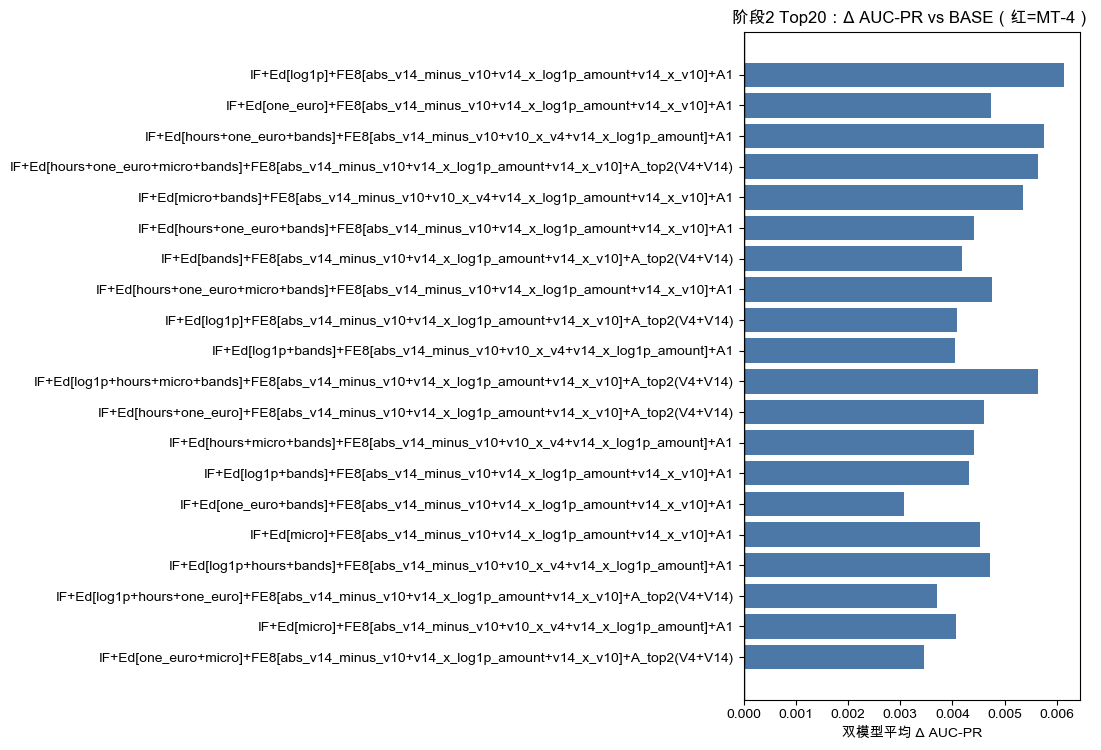

已导出: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/MODEL_FEATURES_V3_contribution_fe8.json /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/FE8_CONTRIBUTION_STABILITY_RESULTS.json
图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/feature-engineering/output/fe8/figures/fe8_stage2_delta_top20.png


In [39]:
# --- 8. 定稿决策 + 导出 + 图 ---
def get_extra_by_label(spec_records, label):
    for rec in spec_records:
        if rec['label'] == label:
            return list(rec['extra_cols'])
    raise KeyError(label)


eligible = stage2_dual[
    stage2_dual['both_models_positive']
    & (stage2_dual['LGB_positive_seed_ratio'] >= 2 / 3)
    & (stage2_dual['XGB_positive_seed_ratio'] >= 2 / 3)
    & (stage2_dual['combo_label'] != BASELINE_LABEL)
    & (stage2_dual['category'] == 'stage2_main')
].copy()

if eligible.empty:
    WINNER_LABEL = MT4_LABEL
    SELECTED_EXTRA = list(MT4_FINAL_EXTRA)
    decision = '阶段2 无稳定优胜组合；保留 MT-4 定稿（IF+hours+log1p+A_top2）。'
else:
    winner = eligible.sort_values(['conservative_score', 'delta_mean_AUC'], ascending=False).iloc[0]
    WINNER_LABEL = winner['combo_label']
    SELECTED_EXTRA = get_extra_by_label(STAGE2_RECORDS, WINNER_LABEL)
    decision = (
        f'优胜: {WINNER_LABEL} | Δ vs BASE={winner["delta_mean_AUC"]:.5f} | '
        f'conservative={winner["conservative_score"]:.5f}'
    )

MODEL_FEATURES_V3 = BASE_FEATURES + [c for c in SELECTED_EXTRA if c not in BASE_FEATURES]
mt4_row = stage2_dual[stage2_dual['combo_label'] == MT4_LABEL]
mt4_delta = float(mt4_row['delta_mean_AUC'].iloc[0]) if not mt4_row.empty else None

print('=== FE-8 定稿 ===')
print(decision)
print('组合:', WINNER_LABEL)
print('MT-4 Δ vs BASE:', mt4_delta)
print('增量列:', [c for c in SELECTED_EXTRA if c not in BASE_FEATURES])

export_payload = {
    'MODEL_FEATURES_V3': MODEL_FEATURES_V3,
    'winner_combo': WINNER_LABEL,
    'decision': decision,
    'selected_extra': [c for c in MODEL_FEATURES_V3 if c not in BASE_FEATURES],
    'stage1_shortlist': SELECTED_FE8_LISTS,
    'stage1_n_combos': len(STAGE1_RECORDS),
    'stage2_n_combos': len(STAGE2_RECORDS),
    'mt4_reference_extra': MT4_FINAL_EXTRA,
    'mt4_reference_label': MT4_LABEL,
    'mt4_delta_vs_base': mt4_delta,
    'fe8_new_features': FE8_NEW_FEATURES,
    'baseline_label': BASELINE_LABEL,
    'stage2_dual_summary_csv': str(STAGE2_DUAL_CSV),
}

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(export_payload, f, ensure_ascii=False, indent=2)

with open(RESULT_PATH, 'w', encoding='utf-8') as f:
    json.dump({
        'stage1_dual_summary': stage1_dual.round(6).to_dict(orient='records'),
        'stage1_shortlist': SELECTED_FE8_LISTS,
        'stage2_dual_summary': stage2_dual.round(6).to_dict(orient='records'),
        'stage2_catalog': stage2_catalog_df.to_dict(orient='records'),
    }, f, ensure_ascii=False, indent=2)

plot_df = stage2_dual.head(20).iloc[::-1].copy()
fig, ax = plt.subplots(figsize=(11, max(6, 0.38 * len(plot_df))))
colors = ['#E45756' if r['combo_label'] == MT4_LABEL else ('#4C78A8' if r['both_models_positive'] else '#BAB0AC') for _, r in plot_df.iterrows()]
ax.barh(plot_df['combo_label'], plot_df['delta_mean_AUC'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('阶段2 Top20：Δ AUC-PR vs BASE（红=MT-4）')
ax.set_xlabel('双模型平均 Δ AUC-PR')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fe8_stage2_delta_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print('已导出:', OUTPUT_PATH, RESULT_PATH)
print('图表:', FIG_DIR / 'fe8_stage2_delta_top20.png')



这两个种子下最好的是 IF + log1p_amount + 3 个 FE8 交叉（abs_v14_minus_v10，v14_x_v10，v14_x_log1p_amount） + one_euro_V4（A1）  

## 阶段 3：Top-5 扩展 seeds 复验

对阶段 2 **conservative_score** 排名前 5 的组合，用 **8 个 seeds**（7, 13, 42, 77, 123, 256, 2026, 3141）× 2 模型复验稳定性。

- 含 `0_BASE`、`MT-4` 参照 + Top-5 主网格 → **112 轮 CV**
- 结果：`fe8_top5_validation_result.json`、`fe8_top5_validation_dual_summary.csv`
- 已跑完时设 `SKIP_TOP5_RUN = True`（cell 1）可只展示历史结果，不重跑


In [ ]:
# --- 9. Top-5 扩展 seeds 复验 ---
def _parse_pipe_cols(s):
    if not isinstance(s, str) or not s.strip() or s == '(none)':
        return []
    return [c.strip() for c in s.split('|')]


def _record_from_row(row, rank_stage2):
    extra = _parse_pipe_cols(row['extra_cols'])
    fe8 = _parse_pipe_cols(row['fe8_cols'])
    hc = _parse_pipe_cols(row['handcrafted_cols'])
    return {
        'combo_id': int(row['combo_id']),
        'stage': 3,
        'category': 'top5_rerun',
        'label': row['combo_label'],
        'handcrafted_cols': hc,
        'fe8_cols': fe8,
        'extra_cols': extra,
        'n_handcrafted': int(row['n_handcrafted']),
        'n_fe8': int(row['n_fe8']),
        'n_extra': int(row['n_extra']),
        'rank_stage2': rank_stage2,
    }


def build_top5_validation_specs(stage2_dual_df):
    refs = stage2_dual_df[stage2_dual_df['combo_label'].isin([BASELINE_LABEL, MT4_LABEL])]
    main = stage2_dual_df[stage2_dual_df['category'] == 'stage2_main'].copy()
    main = main.sort_values(['conservative_score', 'delta_mean_AUC'], ascending=False).head(5)
    records = []
    for _, row in refs.iterrows():
        records.append(_record_from_row(row, 0))
    for i, (_, row) in enumerate(main.iterrows(), start=1):
        records.append(_record_from_row(row, i))
    return records, main


def summarize_top5_validation(raw: pd.DataFrame):
    base = (
        raw[raw['特征组合'] == BASELINE_LABEL]
        .groupby(['模型', 'seed'], as_index=False)['AUC-PR_mean']
        .mean()
        .rename(columns={'AUC-PR_mean': 'BASE_AUC_seed'})
    )
    mt4 = (
        raw[raw['特征组合'] == MT4_LABEL]
        .groupby(['模型', 'seed'], as_index=False)['AUC-PR_mean']
        .mean()
        .rename(columns={'AUC-PR_mean': 'MT4_AUC_seed'})
    )
    merged = raw.merge(base, on=['模型', 'seed'], how='left')
    merged['delta_vs_BASE'] = merged['AUC-PR_mean'] - merged['BASE_AUC_seed']
    merged = merged.merge(mt4, on=['模型', 'seed'], how='left')
    merged['delta_vs_MT4'] = merged['AUC-PR_mean'] - merged['MT4_AUC_seed']

    dual_rows = []
    for label in merged['特征组合'].unique():
        if label in (BASELINE_LABEL, MT4_LABEL):
            continue
        sub = merged[merged['特征组合'] == label]
        lgb = sub[sub['模型'] == 'LightGBM']
        xgb = sub[sub['模型'] == 'XGBoost']
        rank_val = int(sub['rank_stage2'].iloc[0]) if 'rank_stage2' in sub.columns else 0
        dual_rows.append({
            'combo_label': label,
            'rank_stage2': rank_val,
            'delta_LGB_vs_BASE': float(lgb['delta_vs_BASE'].mean()),
            'delta_XGB_vs_BASE': float(xgb['delta_vs_BASE'].mean()),
            'delta_mean_vs_BASE': float(sub['delta_vs_BASE'].mean()),
            'delta_mean_vs_MT4': float(sub['delta_vs_MT4'].mean()),
            'positive_vs_BASE_ratio': float((sub['delta_vs_BASE'] > 0).mean()),
            'conservative_vs_BASE': float(
                sub.groupby('模型')['delta_vs_BASE'].mean().mean()
                - sub.groupby('模型')['delta_vs_BASE'].std().fillna(0).mean()
            ),
        })
    dual = pd.DataFrame(dual_rows)
    top5_rerun = dual[dual['rank_stage2'] > 0].sort_values(
        'conservative_vs_BASE', ascending=False
    )
    return merged, dual, top5_rerun


if 'stage2_dual' not in globals() or stage2_dual is None or stage2_dual.empty:
    if not STAGE2_DUAL_CSV.is_file():
        raise FileNotFoundError(f'未找到阶段2结果: {STAGE2_DUAL_CSV}，请先跑 cell 8')
    _stage2_dual = pd.read_csv(STAGE2_DUAL_CSV)
else:
    _stage2_dual = stage2_dual.copy()

TOP5_SPECS, TOP5_STAGE2_TABLE = build_top5_validation_specs(_stage2_dual)

print('=== 阶段2 Top-5（扩展 seeds 复验对象）===')
display(TOP5_STAGE2_TABLE[['combo_label', 'delta_mean_AUC', 'conservative_score', 'extra_cols']].round(5))

_rank1 = TOP5_STAGE2_TABLE.iloc[0]
_mt4 = _stage2_dual[_stage2_dual['combo_label'] == MT4_LABEL].iloc[0]
print('\n=== 当前排名第1（阶段2: seeds 42, 2026）===')
print('组合:', _rank1['combo_label'])
print(f"超 BASE: Δ={_rank1['delta_mean_AUC']:.5f}")
print(
    f"超 MT-4: Δ={_rank1['delta_mean_AUC'] - _mt4['delta_mean_AUC']:.5f} "
    f"(第1 {_rank1['delta_mean_AUC']:.5f} vs MT4 {_mt4['delta_mean_AUC']:.5f})"
)

_expected_runs = len(TOP5_SPECS) * len(MODELS) * len(TOP5_VALIDATION_SEEDS)
_checkpoint_done = 0
if TOP5_CHECKPOINT.is_file():
    _checkpoint_done = len(pd.read_csv(TOP5_CHECKPOINT))

if SKIP_TOP5_RUN and TOP5_JSON.is_file() and _checkpoint_done >= _expected_runs:
    print(f'\n跳过 Top-5 跑批（SKIP_TOP5_RUN=True，已有 {_checkpoint_done}/{_expected_runs} 轮）')
    with open(TOP5_JSON, encoding='utf-8') as f:
        top5_result = json.load(f)
    top5_rerun_rank = pd.DataFrame(top5_result['top5_rerun_ranking'])
    if TOP5_DUAL_CSV.is_file():
        top5_dual = pd.read_csv(TOP5_DUAL_CSV)
    else:
        top5_dual = top5_rerun_rank.copy()
    print('\n=== 扩展 seeds 复验 Top-5 排名（自 fe8_top5_validation_result.json）===')
    display(top5_rerun_rank.round(5))
    print('复验优胜:', top5_result.get('rerun_winner_label'))
    print('已保存:', TOP5_JSON)
else:
    print(f'\n扩展 seeds: {TOP5_VALIDATION_SEEDS}')
    print(f'轮次: {len(TOP5_SPECS)}组 × 2模型 × {len(TOP5_VALIDATION_SEEDS)}seeds = {_expected_runs}')

    _rank_map = {r['label']: r['rank_stage2'] for r in TOP5_SPECS}
    top5_raw = run_stability_matrix(TOP5_SPECS, TOP5_CHECKPOINT, seeds=TOP5_VALIDATION_SEEDS)
    top5_raw['rank_stage2'] = top5_raw['特征组合'].map(_rank_map)
    top5_seed_df, top5_dual, top5_rerun_rank = summarize_top5_validation(top5_raw)
    top5_raw.to_csv(TOP5_RAW_CSV, index=False, encoding='utf-8-sig')
    top5_dual.to_csv(TOP5_DUAL_CSV, index=False, encoding='utf-8-sig')

    winner = top5_rerun_rank.iloc[0]
    top5_result = {
        'validation_seeds': TOP5_VALIDATION_SEEDS,
        'stage2_rank1_label': _rank1['combo_label'],
        'stage2_rank1_delta_vs_BASE': float(_rank1['delta_mean_AUC']),
        'stage2_rank1_delta_vs_MT4': float(_rank1['delta_mean_AUC'] - _mt4['delta_mean_AUC']),
        'stage2_mt4_delta_vs_BASE': float(_mt4['delta_mean_AUC']),
        'rerun_winner_label': winner['combo_label'],
        'rerun_winner_delta_vs_BASE': float(winner['delta_mean_vs_BASE']),
        'rerun_winner_delta_vs_MT4': float(winner['delta_mean_vs_MT4']),
        'top5_rerun_ranking': top5_rerun_rank.round(6).to_dict(orient='records'),
    }
    with open(TOP5_JSON, 'w', encoding='utf-8') as f:
        json.dump(top5_result, f, ensure_ascii=False, indent=2)

    print('\n=== 扩展 seeds 复验 Top-5 排名 ===')
    display(top5_rerun_rank.round(5))
    print('复验优胜:', winner['combo_label'])
    print('已保存:', TOP5_JSON)


之后换8个种子测试，最好的是IF+hours+one_euro+micro+bands+FE8（abs_v14_minus_v10，v14_x_v10，v14_x_log1p_amount）+A_top2

## 如何解读

### 阶段 1（32 组）
- 纯 `BASE + FE8` 子集（已硬编码 Top-3 shortlist，可跳过跑批）
- 结果：`fe8_stage1_dual_summary.csv`、`fe8_stage1_shortlist.json`

### 阶段 2（194 组）
- **主网格**：`IF × EDA(32) × 入选FE8 × {+A1, +A_top2}` = 192 组
- **参照**：`0_BASE` + MT-4（共 2 组）
- **seeds**：42、2026（×2 模型 → **776 轮**）
- 除 `0_BASE` 外均含 IF + 入选 FE8；Δ 均相对 BASE

### 阶段 3（Top-5 × 8 seeds）
- 对阶段 2 前 5 名做扩展 seed 复验（**112 轮**）
- 看 `fe8_top5_validation_result.json` 中 `rerun_winner_label` 是否与 `stage2_rank1_label` 一致
- 若扩展 seeds 下原第 1 明显回落，定稿应更保守

### checkpoint
矩阵变更后删除 `fe8_stage2_checkpoint.csv` 再跑 cell 7–8。
Top-5 重跑前删除 `fe8_top5_validation_checkpoint.csv`。

